<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>ML/DL</b></center>

<center><b><h1> </b></center>
<center><b><h5>K-means, K-Medoids</b></center>
<pre>    

# Step 1: Import Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load the Dataset
Load Given dataset -  StudentsPerformance.csv

In [11]:
df = pd.read_csv('StudentsPerformance.csv')

In [12]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [17]:
#summarize data
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [14]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


# Step 4: Display PairPlot

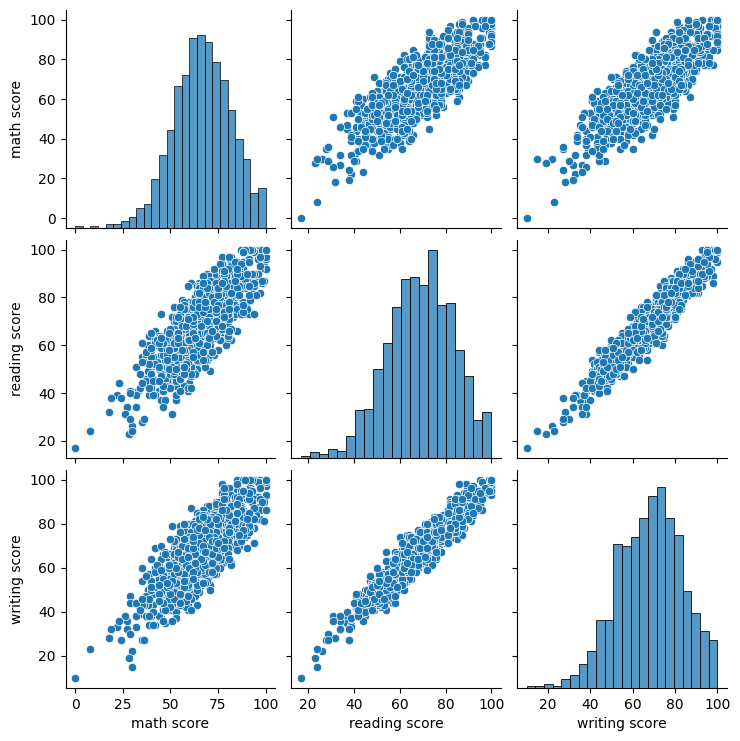

In [18]:
sns.pairplot(df)


# Step 5: Correlation heatmap

<Axes: >

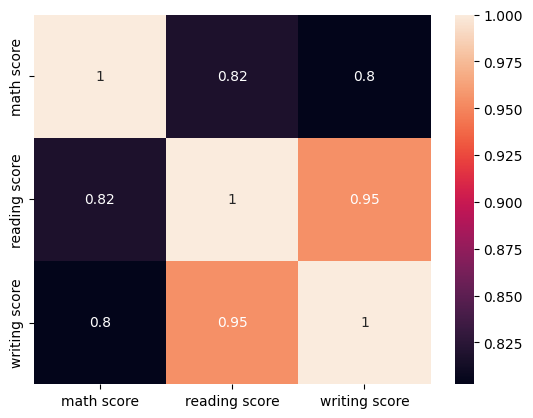

In [21]:
#correlation matrix
a = pd.DataFrame(df.select_dtypes(include=[np.number]).corr())
sns.heatmap(a, annot=True)

# Step 6: Distribution of numerical features

array([[<Axes: title={'center': 'math score'}>,
        <Axes: title={'center': 'reading score'}>],
       [<Axes: title={'center': 'writing score'}>, <Axes: >]],
      dtype=object)

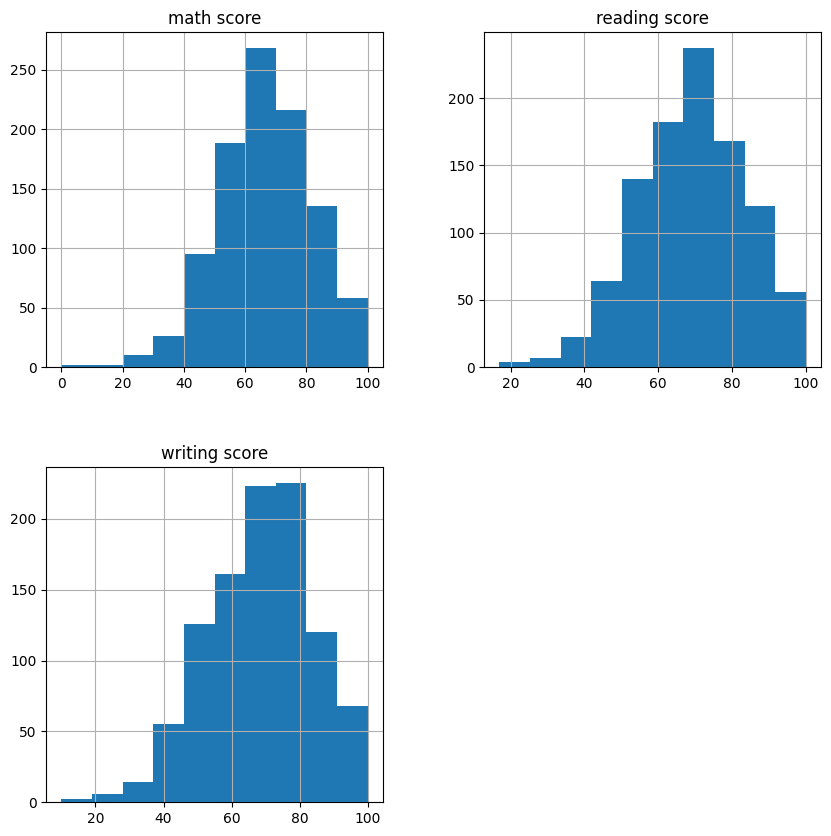

In [22]:
#distibution of numerical features
df.hist(figsize=(10,10))


# Step 7: Apply StandardScaler

In [36]:
#standard sclar
from sklearn.preprocessing import StandardScaler
X=df[['math score','reading score','writing score']]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled_df=pd.DataFrame(X_scaled,columns=X.columns)
print(X_scaled_df.head())

   math score  reading score  writing score
0    0.390024       0.193999       0.391492
1    0.192076       1.427476       1.313269
2    1.577711       1.770109       1.642475
3   -1.259543      -0.833899      -1.583744
4    0.653954       0.605158       0.457333


# Step 8: Elbow method to find optimal k

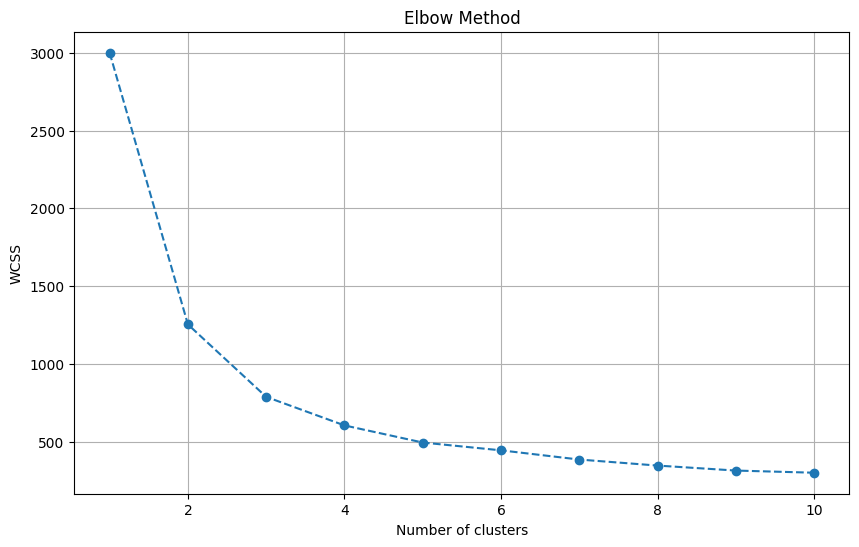

In [37]:
#elbow method to find optimal k
from sklearn.cluster import KMeans
wcss = []
k_range = range(1, 11)

for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(k_range, wcss, marker='o',linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

# Step 9:Based on the elbow plot, choose an appropriate k value (e.g., k=3)

In [38]:
#k =3
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

#new column for cluster labels
df['Cluster_KMeans'] = y_kmeans

# Step 10: Print Cluster Center

In [39]:
#print cluster centers
print("Cluster Centers (Scaled):")
print(kmeans.cluster_centers_)

print('\nCluster Centers (Original Scale):')
print(scaler.inverse_transform(kmeans.cluster_centers_))

Cluster Centers (Scaled):
[[-0.04951336 -0.04870596 -0.01529686]
 [-1.18720058 -1.26762535 -1.28838441]
 [ 1.03099793  1.09485536  1.06358515]]

Cluster Centers (Original Scale):
[[65.33860045 68.45823928 67.82167043]
 [48.09638554 50.67068273 48.48594378]
 [81.71428571 85.1461039  84.20779221]]


# Step 11: Plot Cluster

In [ ]:
#plot clusters
plt.figure(figsize=(10,6))


# Step 12:Analyze clusters 

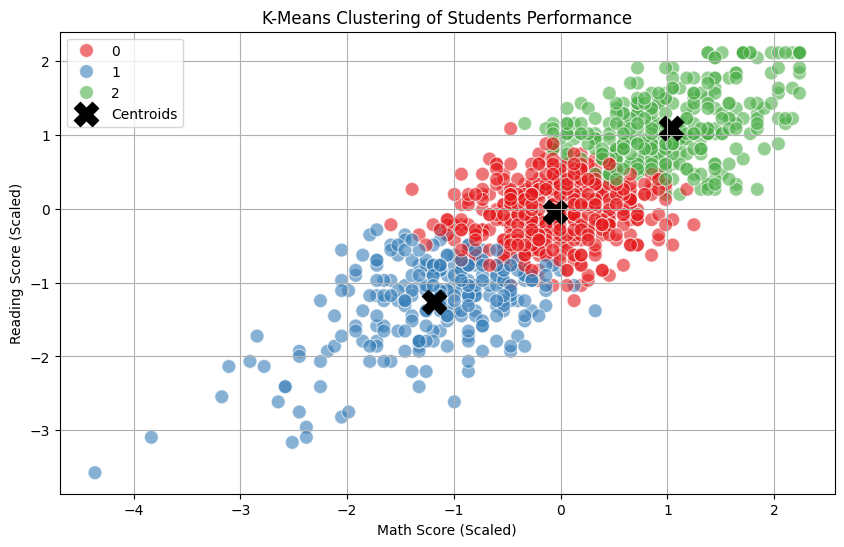

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1],hue=y_kmeans, palette='Set1', s=100, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='black', marker='X', label='Centroids')
plt.title('K-Means Clustering of Students Performance')
plt.xlabel('Math Score (Scaled)')
plt.ylabel('Reading Score (Scaled)')
plt.legend()
plt.grid()
plt.show()

# Step 13: Perform K-Medoids

In [41]:
pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 2.1 MB/s  0:00:00eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp311-cp311-macosx_15_0_arm64.whl size=401469 sha256=e7f8c955157fb188045399b5f44149b70ea3efb1d2f618164d95b48df535b795
  Stored in directory: /Users/kunj/Library/Caches/pip/wheels/9c/cb/bd/4f19f79eee4fe83d1303d9be845bf9b07507dcac5439fa30ba
Successfully built scikit-learn-extra

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [42]:
from sklearn_extra.cluster import KMedoids

kmediods = KMedoids(n_clusters=optimal_k, random_state=42, method='pam')
y_kmedoids = kmediods.fit_predict(X_scaled)
    
df['Cluster_KMedoids'] = y_kmedoids

# Step:14 Comparison of K-means and K-medoids Clusters

# Step: 15 | USE KMEAN++
